In [14]:
!pip install segmentation-models-pytorch albumentations

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [15]:
IMAGE_DIR = '/kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset/train'
MASK_DIR = '/kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset/test' 

# filter for 'urban' land cover. DeepGlobe uses RGB masks; we convert this to a binary mask.
class UrbanDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        # Read Image
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Read Mask 
        mask = cv2.imread(self.mask_paths[idx])
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        
        # Extract urban land (In DeepGlobe, urban land is represented by a specific RGB color, e.g., Cyan [0,255,255])
        # We create a binary mask: 1 for Urban, 0 for Background
        binary_mask = np.all(mask == [0, 255, 255], axis=-1).astype(np.float32)
        
        if self.transform:
            augmented = self.transform(image=img, mask=binary_mask)
            img = augmented['image']
            binary_mask = augmented['mask']
            
        return img, binary_mask.unsqueeze(0) # Add channel dimension for PyTorch

# Augmentations to make the model robust
transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [16]:
# Initialize U-Net with a pre-trained ResNet34 backbone
model = smp.Unet(
    encoder_name="resnet34",        
    encoder_weights="imagenet",     
    in_channels=3,                  
    classes=1, # Binary classification: Urban vs Non-Urban                 
)
model.to(device)

# Define Custom Loss (Dice Loss + Binary Cross Entropy) and Optimizer
criterion = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [17]:
import glob
import os
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader


all_images = sorted(glob.glob(os.path.join(IMAGE_DIR, '*_sat.jpg')))


all_masks = [img_path.replace('_sat.jpg', '_mask.png') for img_path in all_images]


if len(all_masks) > 0 and not os.path.exists(all_masks[0]):
    print(f"Warning: Could not find {all_masks[0]}")
    print("Attempting uppercase .PNG extension instead...")
    all_masks = [img_path.replace('_sat.jpg', '_mask.PNG') for img_path in all_images]

# Verify lengths match before splitting
print(f"Ready to split: {len(all_images)} images and {len(all_masks)} masks.")

# 3. Split into training and validation sets (80% train, 20% validation)
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    all_images, all_masks, test_size=0.2, random_state=42
)


train_dataset = UrbanDataset(train_imgs, train_masks, transform=transform)
val_dataset = UrbanDataset(val_imgs, val_masks, transform=transform)


train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)

print(f"Created train_loader with {len(train_loader)} batches.")

Ready to split: 803 images and 803 masks.
Created train_loader with 81 batches.


In [18]:
# Training Loop Structure
EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    
    # Loop through batches of images and masks
    for images, masks in train_loader: 
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        
        # Forward Pass
        predictions = model(images)
        
        # Calculate Custom Dice Loss
        loss = criterion(predictions, masks)
        
        # Backward Pass (Backpropagation)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
    print(f"Epoch: {epoch+1}/{EPOCHS} | Training Dice Loss: {train_loss/len(train_loader):.4f}")

Epoch: 1/20 | Training Dice Loss: 0.5301
Epoch: 2/20 | Training Dice Loss: 0.3618
Epoch: 3/20 | Training Dice Loss: 0.3475
Epoch: 4/20 | Training Dice Loss: 0.3626
Epoch: 5/20 | Training Dice Loss: 0.3517
Epoch: 6/20 | Training Dice Loss: 0.3298
Epoch: 7/20 | Training Dice Loss: 0.2963
Epoch: 8/20 | Training Dice Loss: 0.3048
Epoch: 9/20 | Training Dice Loss: 0.2811
Epoch: 10/20 | Training Dice Loss: 0.3003
Epoch: 11/20 | Training Dice Loss: 0.2894
Epoch: 12/20 | Training Dice Loss: 0.2725
Epoch: 13/20 | Training Dice Loss: 0.3029
Epoch: 14/20 | Training Dice Loss: 0.2958
Epoch: 15/20 | Training Dice Loss: 0.2497
Epoch: 16/20 | Training Dice Loss: 0.2555
Epoch: 17/20 | Training Dice Loss: 0.2735
Epoch: 18/20 | Training Dice Loss: 0.2595
Epoch: 19/20 | Training Dice Loss: 0.2577
Epoch: 20/20 | Training Dice Loss: 0.2381


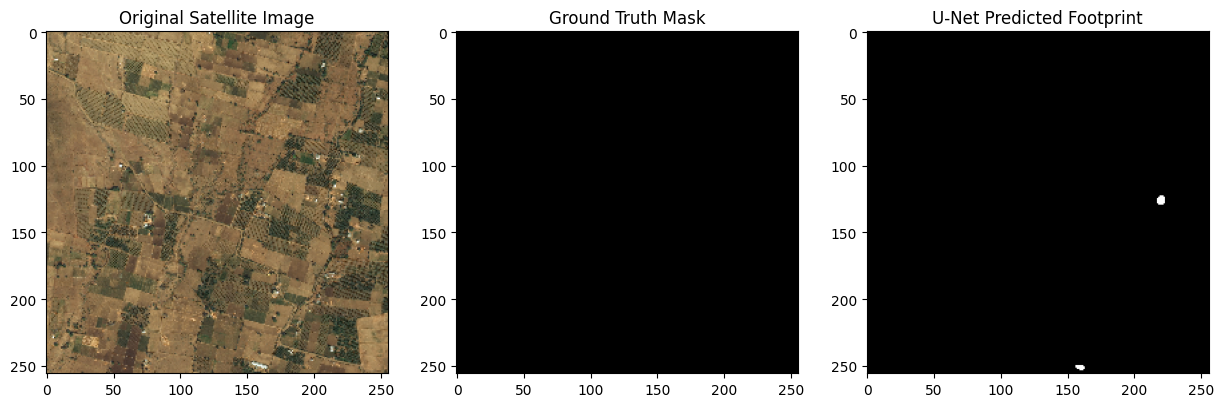

In [19]:
# Evaluation mode
model.eval()

# Grab a single sample from validation/test set
sample_img, sample_mask = next(iter(val_loader)) 
sample_img = sample_img.to(device)

with torch.no_grad():
    pred_mask = model(sample_img)
    # Apply sigmoid to convert logits to probabilities, then threshold at 0.5
    pred_mask = (torch.sigmoid(pred_mask) > 0.5).float()


# Define the exact mean and std used in our Albumentations transform
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# Move tensor to CPU, remove batch dimension, and change shape to (Height, Width, Channels)
sample_img_display = sample_img[0].cpu().permute(1, 2, 0).numpy()

# Reverse the normalization: Multiply by std and add mean
sample_img_display = (sample_img_display * std) + mean

# Clip the values to strictly [0, 1] to prevent matplotlib warnings about out-of-bounds data
sample_img_display = np.clip(sample_img_display, 0, 1)


true_mask_display = sample_mask[0].cpu().squeeze().numpy()
pred_mask_display = pred_mask[0].cpu().squeeze().numpy()

# Plotting
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(sample_img_display)
ax[0].set_title("Original Satellite Image")

ax[1].imshow(true_mask_display, cmap='gray')
ax[1].set_title("Ground Truth Mask")

ax[2].imshow(pred_mask_display, cmap='gray')
ax[2].set_title("U-Net Predicted Footprint")

plt.show()

In [20]:
import torch.nn as nn
import torch.nn.functional as F

class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceBCELoss, self).__init__()
        self.smooth = smooth

    def forward(self, inputs, targets):
        # Apply sigmoid to convert logits to probabilities (0 to 1)
        inputs = torch.sigmoid(inputs)       
        
        # Flatten label and prediction tensors
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        
        # Calculate Smoothed Dice Loss
        intersection = (inputs * targets).sum()                            
        dice_loss = 1 - (2. * intersection + self.smooth) / (inputs.sum() + targets.sum() + self.smooth)  
        
        # Calculate Binary Cross Entropy (BCE)
        bce_loss = F.binary_cross_entropy(inputs, targets, reduction='mean')
        
        # Combine them (BCE helps with pixel-level classification, Dice helps with overall shape)
        return bce_loss + dice_loss

# Initialize U-Net with a pre-trained ResNet34 backbone
model = smp.Unet(
    encoder_name="resnet34",        
    encoder_weights="imagenet",     
    in_channels=3,                  
    classes=1,                 
)
model.to(device)

# Replace the old criterion with our custom robust loss
criterion = DiceBCELoss(smooth=1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [21]:
# Training Loop Structure
EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    
    # Loop through batches of images and masks
    for images, masks in train_loader: 
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        
        # Forward Pass
        predictions = model(images)
        
        # Calculate Custom Dice Loss
        loss = criterion(predictions, masks)
        
        # Backward Pass (Backpropagation)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
    print(f"Epoch: {epoch+1}/{EPOCHS} | Training Dice Loss: {train_loss/len(train_loader):.4f}")

Epoch: 1/20 | Training Dice Loss: 0.8576
Epoch: 2/20 | Training Dice Loss: 0.6406
Epoch: 3/20 | Training Dice Loss: 0.6145
Epoch: 4/20 | Training Dice Loss: 0.5374
Epoch: 5/20 | Training Dice Loss: 0.5163
Epoch: 6/20 | Training Dice Loss: 0.4708
Epoch: 7/20 | Training Dice Loss: 0.4650
Epoch: 8/20 | Training Dice Loss: 0.4665
Epoch: 9/20 | Training Dice Loss: 0.4755
Epoch: 10/20 | Training Dice Loss: 0.4984
Epoch: 11/20 | Training Dice Loss: 0.3927
Epoch: 12/20 | Training Dice Loss: 0.4337
Epoch: 13/20 | Training Dice Loss: 0.3898
Epoch: 14/20 | Training Dice Loss: 0.4354
Epoch: 15/20 | Training Dice Loss: 0.3584
Epoch: 16/20 | Training Dice Loss: 0.3744
Epoch: 17/20 | Training Dice Loss: 0.3296
Epoch: 18/20 | Training Dice Loss: 0.3460
Epoch: 19/20 | Training Dice Loss: 0.3363
Epoch: 20/20 | Training Dice Loss: 0.3384


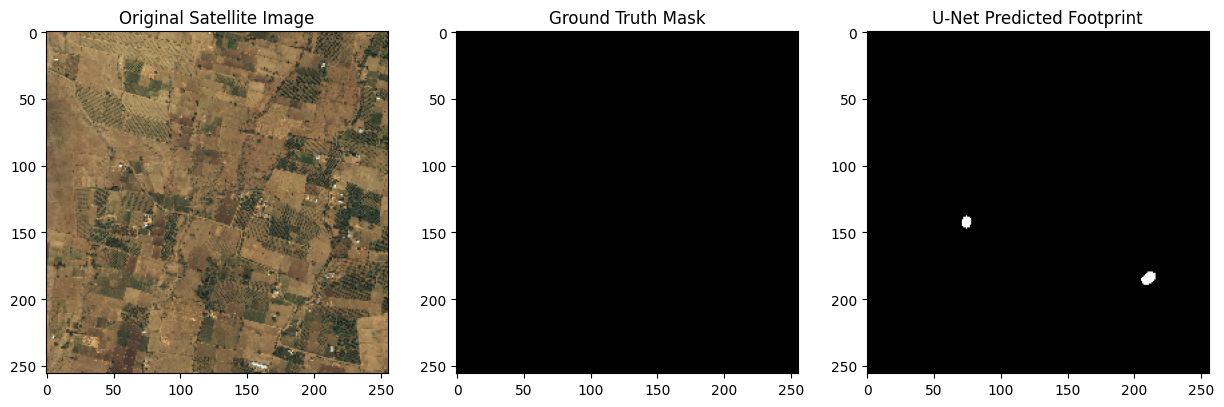

In [22]:
# Evaluation mode
model.eval()

# Grab a single sample from validation/test set
sample_img, sample_mask = next(iter(val_loader)) 
sample_img = sample_img.to(device)

with torch.no_grad():
    pred_mask = model(sample_img)
    # Apply sigmoid to convert logits to probabilities, then threshold at 0.5
    pred_mask = (torch.sigmoid(pred_mask) > 0.5).float()


# Define the exact mean and std used in our Albumentations transform
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# Move tensor to CPU, remove batch dimension, and change shape to (Height, Width, Channels)
sample_img_display = sample_img[0].cpu().permute(1, 2, 0).numpy()

# Reverse the normalization: Multiply by std and add mean
sample_img_display = (sample_img_display * std) + mean

# Clip the values to strictly [0, 1] to prevent matplotlib warnings about out-of-bounds data
sample_img_display = np.clip(sample_img_display, 0, 1)


true_mask_display = sample_mask[0].cpu().squeeze().numpy()
pred_mask_display = pred_mask[0].cpu().squeeze().numpy()


# Convert the binary mask (0.0 and 1.0) to an 8-bit image (0 and 255) for OpenCV
mask_8u = (pred_mask_display * 255).astype(np.uint8)

# Find all distinct blobs (connected components)
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_8u, connectivity=8)

# Create a blank canvas to hold our cleaned-up image
cleaned_mask = np.zeros_like(mask_8u)

# Set minimum pixel area threshold (e.g., anything smaller than 50 pixels is deleted)
MIN_AREA = 50 

# Loop through every detected blob (starting at 1 to skip the black background)
for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    
    # If the blob is large enough to be a building, copy it to the clean canvas
    if area >= MIN_AREA:
        cleaned_mask[labels == i] = 1 # Keep it as 1 for matplotlib plotting

# Overwrite the original noisy prediction with the cleaned version
pred_mask_display = cleaned_mask

# Plotting
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(sample_img_display)
ax[0].set_title("Original Satellite Image")

ax[1].imshow(true_mask_display, cmap='gray')
ax[1].set_title("Ground Truth Mask")

ax[2].imshow(pred_mask_display, cmap='gray')
ax[2].set_title("U-Net Predicted Footprint")

plt.show()